In [24]:
import kagglehub
from kagglehub import KaggleDatasetAdapter


In [25]:
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "nih-chest-xrays/data",
    "Data_Entry_2017.csv"
)

print(df.shape)
print(df.head())

(112120, 12)
        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   
3           81              M            PA                 2500     2048   
4           81              F            PA                 2582     2991   

   OriginalImagePixelSpacing[x     y]  Unnamed: 11  
0                        0.143  0.143 

In [26]:
print ("Dataset Shape:",df.shape)
print(("\nColumns"))
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Value")
print(df.isnull().sum())


Dataset Shape: (112120, 12)

Columns
['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']

Data Types:
Image Index                     object
Finding Labels                  object
Follow-up #                      int64
Patient ID                       int64
Patient Age                      int64
Patient Gender                  object
View Position                   object
OriginalImage[Width              int64
Height]                          int64
OriginalImagePixelSpacing[x    float64
y]                             float64
Unnamed: 11                    float64
dtype: object

Missing Value
Image Index                         0
Finding Labels                      0
Follow-up #                         0
Patient ID                          0
Patient Age                         0
Patient Gender                      0
View Position             

In [27]:
label_counts=df["Finding Labels"].value_counts()
print(label_counts.head(20))


Finding Labels
No Finding                           60361
Infiltration                          9547
Atelectasis                           4215
Effusion                              3955
Nodule                                2705
Pneumothorax                          2194
Mass                                  2139
Effusion|Infiltration                 1603
Atelectasis|Infiltration              1350
Consolidation                         1310
Atelectasis|Effusion                  1165
Pleural_Thickening                    1126
Cardiomegaly                          1093
Emphysema                              892
Infiltration|Nodule                    829
Atelectasis|Effusion|Infiltration      737
Fibrosis                               727
Edema                                  628
Cardiomegaly|Effusion                  484
Consolidation|Infiltration             441
Name: count, dtype: int64


In [28]:
indivisual_labels=df["Finding Labels"].str.split("|").explode()
label_distribution=indivisual_labels.value_counts()
print(label_distribution)

Finding Labels
No Finding            60361
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
Name: count, dtype: int64


In [29]:
pneumonia_positive = df["Finding Labels"].str.contains(
    "Pneumonia", 
    case=False, 
    na=False
)

print("Pneumonia-positive images:", pneumonia_positive.sum())
print("Pneumonia-negative images:", (~pneumonia_positive).sum())

Pneumonia-positive images: 1431
Pneumonia-negative images: 110689


In [30]:
total = len(df)

pneumonia_percentage = (pneumonia_positive.sum() / total) * 100
negative_percentage = ((~pneumonia_positive).sum() / total) * 100

print(f"Pneumonia-positive: {pneumonia_percentage:.2f}%")
print(f"Pneumonia-negative: {negative_percentage:.2f}%")

Pneumonia-positive: 1.28%
Pneumonia-negative: 98.72%


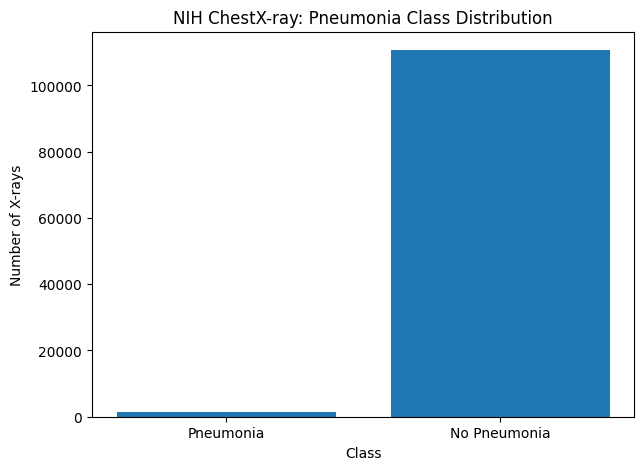

In [31]:
import matplotlib.pyplot as plt

labels = ["Pneumonia", "No Pneumonia"]
counts = [pneumonia_positive.sum(), (~pneumonia_positive).sum()]

plt.figure(figsize=(7, 5))
plt.bar(labels, counts)

plt.title("NIH ChestX-ray: Pneumonia Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of X-rays")

plt.show()

In [32]:
unique_patients = df["Patient ID"].nunique()

print("Total X-ray images:", len(df))
print("Unique patients:", unique_patients)

Total X-ray images: 112120
Unique patients: 30805


In [33]:
images_per_patient = df["Patient ID"].value_counts()

print(images_per_patient.describe())


count    30805.000000
mean         3.639669
std          7.266734
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        184.000000
Name: count, dtype: float64


In [34]:
age_stats = df["Patient Age"].describe()

print(age_stats)

count    112120.000000
mean         46.901463
std          16.839923
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max         414.000000
Name: Patient Age, dtype: float64


In [35]:
invalid_age = df[df["Patient Age"] > 100]

print("Records with age > 100:", len(invalid_age))
print(invalid_age[["Patient ID", "Patient Age"]].head(20))

Records with age > 100: 16
        Patient ID  Patient Age
20852         5567          412
46965        11973          414
48284        12238          148
55742        13950          148
58650        14520          150
62929        15558          149
74884        18366          152
78795        19346          151
84810        20900          411
85404        21047          412
86264        21275          413
91369        22811          412
95794        25206          153
98495        26028          154
101194       26871          155
104590       27989          155
